# Previsão de Default em Cartão de Crédito
### Suporte à Tomada de Decisão Estratégica em Gestão de Risco

**Autor:** Felipe da Rocha Ferreira — 211038342  
**Disciplina:** Controle Estatístico de Processos (CEP)  
**Professor:** André Luiz Marques Serrano  
**Data:** Abril de 2026

---

## Resumo Executivo

Este projeto desenvolve um modelo de aprendizado de máquina supervisionado para prever a inadimplência de clientes de cartão de crédito com base em perfil demográfico e histórico de pagamentos. O problema é enquadrado como **classificação binária** e visa apoiar decisões estratégicas de gestão de risco financeiro, como concessão de crédito, definição de limites e acionamento de políticas de cobrança preventiva.

| | |
|---|---|
| **Dataset** | Default of Credit Card Clients — UCI / Kaggle |
| **Tipo de problema** | Classificação binária supervisionada |
| **Métrica principal** | AUC-ROC |
| **Modelos avaliados** | Regressão Logística, Árvore de Decisão, Random Forest, XGBoost |

---
## 1. Definição do Problema

### 1.1 Descrição do Problema

O risco de crédito é um dos pilares centrais da gestão estratégica em instituições financeiras. Quando um cliente de cartão de crédito deixa de pagar sua fatura (*default*), a instituição emissora incorre em perdas financeiras diretas e enfrenta desafios regulatórios relacionados à manutenção de capital mínimo (Basileia III).

Este projeto propõe prever se um cliente irá inadimplir no mês seguinte com base em seu perfil e histórico dos últimos seis meses, permitindo à instituição acionar políticas preventivas de forma direcionada.

### 1.2 Premissas e Hipóteses

- O **histórico recente de atrasos** (últimos 3 a 6 meses) é o preditor mais forte de default futuro.
- O **nível de utilização do limite de crédito** tem relação positiva com a probabilidade de inadimplência.
- **Variáveis demográficas** (escolaridade, estado civil) possuem poder preditivo secundário, relevante quando combinadas com variáveis financeiras.
- **Modelos baseados em árvores** devem superar modelos lineares, dada a não-linearidade esperada nas interações entre variáveis.
- O dataset é **desbalanceado** (~22% de default), exigindo métricas além da acurácia simples.

### 1.3 Restrições e Condições de Seleção dos Dados

- Todos os 30.000 registros serão utilizados, sem filtros adicionais.
- Variáveis identificadoras (ID do cliente) serão removidas antes da modelagem.
- Variáveis categóricas serão codificadas adequadamente antes do treinamento.
- O desbalanceamento de classes será tratado via `class_weight` ou SMOTE, conforme análise exploratória.

---
## 2. Instalação de Dependências e Imports

In [1]:
# Importação da base de dados
import os
import kagglehub

# Manipulação de dados
import pandas as pd
import numpy as np
import time

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    ConfusionMatrixDisplay
)

# Desbalanceamento
from imblearn.over_sampling import SMOTE

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configurações de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports realizados com sucesso!')

Imports realizados com sucesso!


---
## 3. Carga e Preparação dos Dados

### 3.1 Carregamento do Dataset

O dataset contém 30.000 registros de clientes de cartão de crédito em Taiwan, com informações demográficas, histórico de pagamentos e faturas dos últimos seis meses (abril a setembro de 2005).

### 3.1.1 Dicionário de Dados

Descrição completa de cada variável do dataset, com os códigos originais antes de qualquer tratamento:

| Variável | Descrição |
|---|---|
| `ID` | Identificador de cada cliente |
| `LIMIT_BAL` | Valor do crédito concedido em NT$ (inclui crédito individual e familiar/suplementar) |
| `SEX` | Gênero (1 = masculino, 2 = feminino) |
| `EDUCATION` | Escolaridade (1 = pós-graduação, 2 = superior, 3 = ensino médio, 4 = outros, 5 = desconhecido, 6 = desconhecido) |
| `MARRIAGE` | Estado civil (1 = casado, 2 = solteiro, 3 = outros) |
| `AGE` | Idade em anos |
| `PAY_0` | Status de pagamento em setembro/2005 (-1 = pago em dia, 1 = atraso de 1 mês, 2 = atraso de 2 meses, ..., 8 = atraso de 8 meses, 9 = atraso de 9 meses ou mais) |
| `PAY_2` | Status de pagamento em agosto/2005 (mesma escala) |
| `PAY_3` | Status de pagamento em julho/2005 (mesma escala) |
| `PAY_4` | Status de pagamento em junho/2005 (mesma escala) |
| `PAY_5` | Status de pagamento em maio/2005 (mesma escala) |
| `PAY_6` | Status de pagamento em abril/2005 (mesma escala) |
| `BILL_AMT1` | Valor da fatura em setembro/2005 (NT$) |
| `BILL_AMT2` | Valor da fatura em agosto/2005 (NT$) |
| `BILL_AMT3` | Valor da fatura em julho/2005 (NT$) |
| `BILL_AMT4` | Valor da fatura em junho/2005 (NT$) |
| `BILL_AMT5` | Valor da fatura em maio/2005 (NT$) |
| `BILL_AMT6` | Valor da fatura em abril/2005 (NT$) |
| `PAY_AMT1` | Valor pago em setembro/2005 (NT$) |
| `PAY_AMT2` | Valor pago em agosto/2005 (NT$) |
| `PAY_AMT3` | Valor pago em julho/2005 (NT$) |
| `PAY_AMT4` | Valor pago em junho/2005 (NT$) |
| `PAY_AMT5` | Valor pago em maio/2005 (NT$) |
| `PAY_AMT6` | Valor pago em abril/2005 (NT$) |
| `default.payment.next.month` | Variável-alvo: inadimplência no mês seguinte (1 = sim, 0 = não) |
---
> **Nota:** os valores 0, 5 e 6 em `EDUCATION` e o valor 0 em `MARRIAGE` não constam na documentação oficial do dataset. Na seção 3.4, esses registros são agrupados na categoria "outros" para evitar ruído na modelagem.

In [2]:
# Download do dataset
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Path to dataset files:", path)

# Localizar o arquivo CSV dentro da pasta baixada
files = os.listdir(path)
print("Arquivos disponíveis:", files)

# Carregar o CSV
df = pd.read_csv(os.path.join(path, files[0]))

print(f'Shape: {df.shape}')
df.head()

Path to dataset files: C:\Users\Felipe\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1
Arquivos disponíveis: ['UCI_Credit_Card.csv']
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 3.2 Limpeza Inicial

A coluna `ID`, que é apenas um identificador sem valor preditivo, foi removida e o nome da variável-alvo foi padronizado para `default`.

In [3]:
# Remover coluna identificadora
df.drop(columns=['ID'], inplace=True)

# Padronizar nome da variável-alvo
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

print('Colunas após limpeza:')
print(df.columns.tolist())

Colunas após limpeza:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


### 3.3 Inspeção Geral

In [4]:
print('========== Informações gerais ==========')
display(df.info())

print('\n=== Valores ausentes por coluna ===')
print(df.isnull().sum())

========== Informações gerais ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_A

None


=== Valores ausentes por coluna ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


In [5]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


### 3.4 Tratamento de Categorias Inconsistentes

As variáveis `EDUCATION` e `MARRIAGE` possuem categorias não documentadas na literatura original (valores 0, 5 e 6 em `EDUCATION`; valor 0 em `MARRIAGE`). Esses registros são agrupados na categoria `outros`.

In [6]:
print('Antes do tratamento:')
print('EDUCATION:', df['EDUCATION'].value_counts().sort_index().to_dict())
print('MARRIAGE: ', df['MARRIAGE'].value_counts().sort_index().to_dict())

# Agrupar categorias não documentadas em 'outros' (4 e 3 respectivamente)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})

print('\nApós tratamento:')
print('EDUCATION:', df['EDUCATION'].value_counts().sort_index().to_dict())
print('MARRIAGE: ', df['MARRIAGE'].value_counts().sort_index().to_dict())

Antes do tratamento:
EDUCATION: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE:  {0: 54, 1: 13659, 2: 15964, 3: 323}

Após tratamento:
EDUCATION: {1: 10585, 2: 14030, 3: 4917, 4: 468}
MARRIAGE:  {1: 13659, 2: 15964, 3: 377}


### 3.5 Divisão dos Dados

Divisão em treino (80%) e teste (20%), com estratificação para manter a proporção de defaults em cada partição. A validação dos hiperparâmetros é feita via validação cruzada (5-fold) dentro do próprio treino, nas seções 5.2 e 6. O scaler é ajustado apenas no treino para evitar data leakage.

In [7]:
X = df.drop(columns=['default'])
y = df['default']

# Divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:>6} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Teste:  {X_test.shape[0]:>6} registros ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nProporção de default — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')

Treino:  24000 registros (80.0%)
Teste:    6000 registros (20.0%)

Proporção de default — treino: 0.221 | teste: 0.221


In [ ]:
# Normalização — fit apenas no treino
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test

print('Normalização concluída.')
print(f'Média no treino (esperado ~0): {X_train_sc.mean():.4f}')
print(f'Desvio padrão no treino (esperado ~1): {X_train_sc.std():.4f}')

Normalização concluída.
Média no treino (esperado ~0): 0.0000
Desvio padrão no treino (esperado ~1): 1.0000


---
## 4. Análise Exploratória de Dados (EDA)

Objetivo: entender a distribuição das variáveis, identificar padrões relevantes e levantar evidências que orientem as decisões de modelagem.

### 4.1 Distribuição da Variável-Alvo

O desbalanceamento entre as classes foi verificado. Espera-se ~22% de defaults, o que exigirá atenção especial nas métricas e no tratamento durante a modelagem.

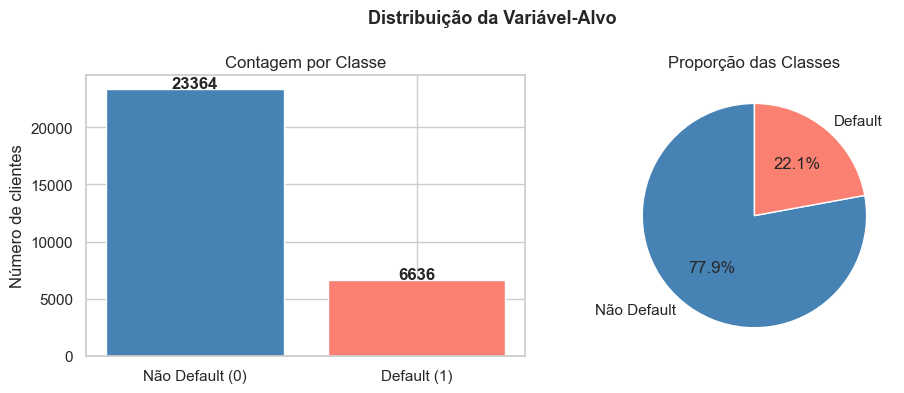

Proporção de default: 22.12%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = y.value_counts()
axes[0].bar(['Não Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Não Default', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporção das Classes')

plt.suptitle('Distribuição da Variável-Alvo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Proporção de default: {y.mean():.2%}')

### 4.2 Distribuição das Variáveis Demográficas

Analisou-se como as variáveis de perfil se distribuem e se há diferença na taxa de default entre grupos.

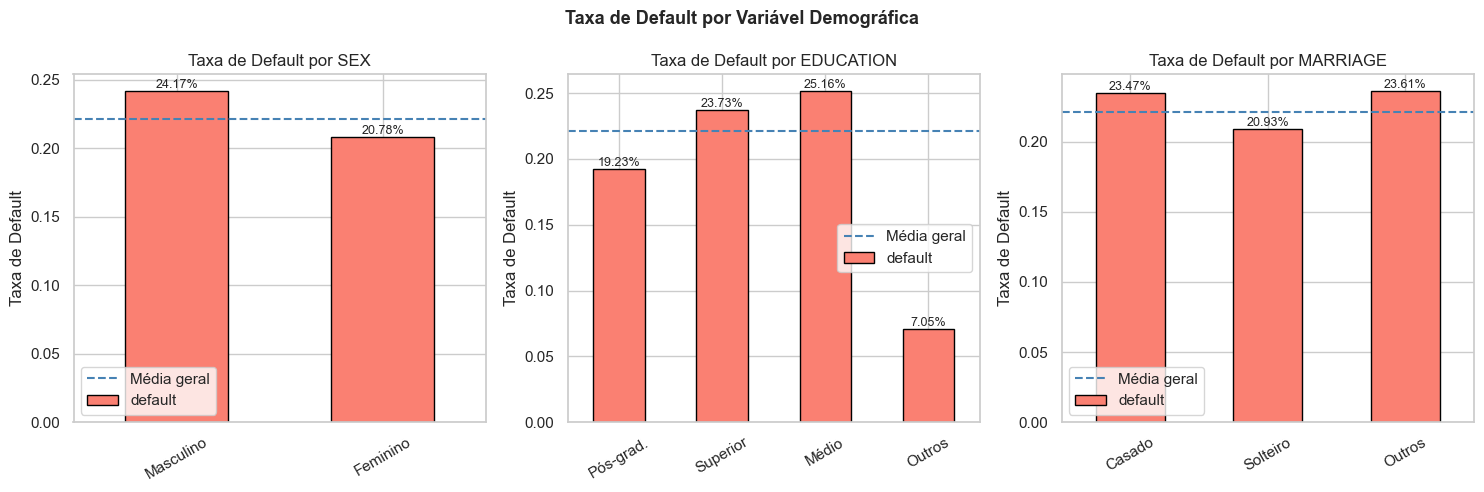

In [10]:
demo_vars = {
    'SEX':       {1: 'Masculino', 2: 'Feminino'},
    'EDUCATION': {1: 'Pós-grad.', 2: 'Superior', 3: 'Médio', 4: 'Outros'},
    'MARRIAGE':  {1: 'Casado', 2: 'Solteiro', 3: 'Outros'}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, labels) in zip(axes, demo_vars.items()):
    default_rate = df.groupby(col)['default'].mean().rename(index=labels)
    default_rate.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(f'Taxa de Default por {col}')
    ax.set_ylabel('Taxa de Default')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y.mean(), color='steelblue', linestyle='--', label='Média geral')
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Taxa de Default por Variável Demográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Distribuição da Idade e do Limite de Crédito

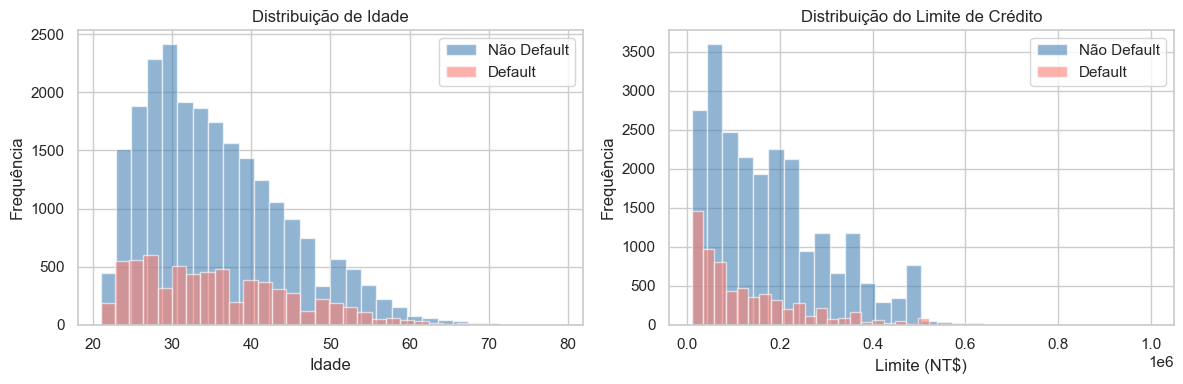

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0, 'Não Default', 'steelblue'), (1, 'Default', 'salmon')]:
    subset = df[df['default'] == val]
    axes[0].hist(subset['AGE'], bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(subset['LIMIT_BAL'], bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].set_title('Distribuição do Limite de Crédito')
axes[1].set_xlabel('Limite (NT$)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4 Histórico de Pagamento vs. Default

As variáveis `PAY_0` a `PAY_6` registram o status de pagamento mensal. Valores positivos indicam meses de atraso — é esperado que eles sejam os preditores mais fortes.

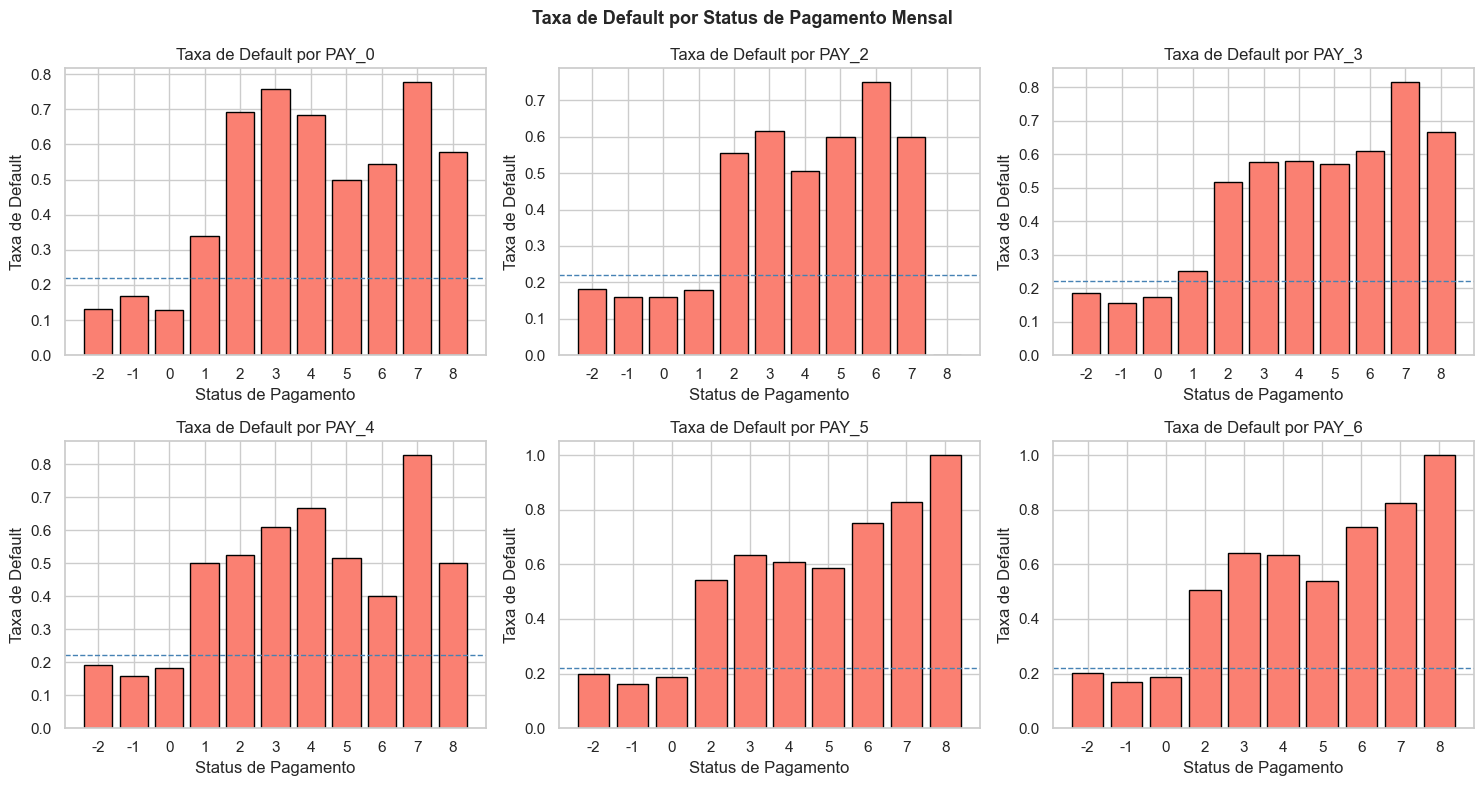

In [12]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    default_rate = df.groupby(col)['default'].mean()
    axes[i].bar(default_rate.index.astype(str), default_rate.values, color='salmon', edgecolor='black')
    axes[i].set_title(f'Taxa de Default por {col}')
    axes[i].set_xlabel('Status de Pagamento')
    axes[i].set_ylabel('Taxa de Default')
    axes[i].axhline(y.mean(), color='steelblue', linestyle='--', linewidth=1)

plt.suptitle('Taxa de Default por Status de Pagamento Mensal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Matriz de Correlação

Por meio da Matriz de Correlação, é possível visualizar as correlações entre as variáveis numéricas e a variável-alvo para identificar os atributos mais associados ao default.

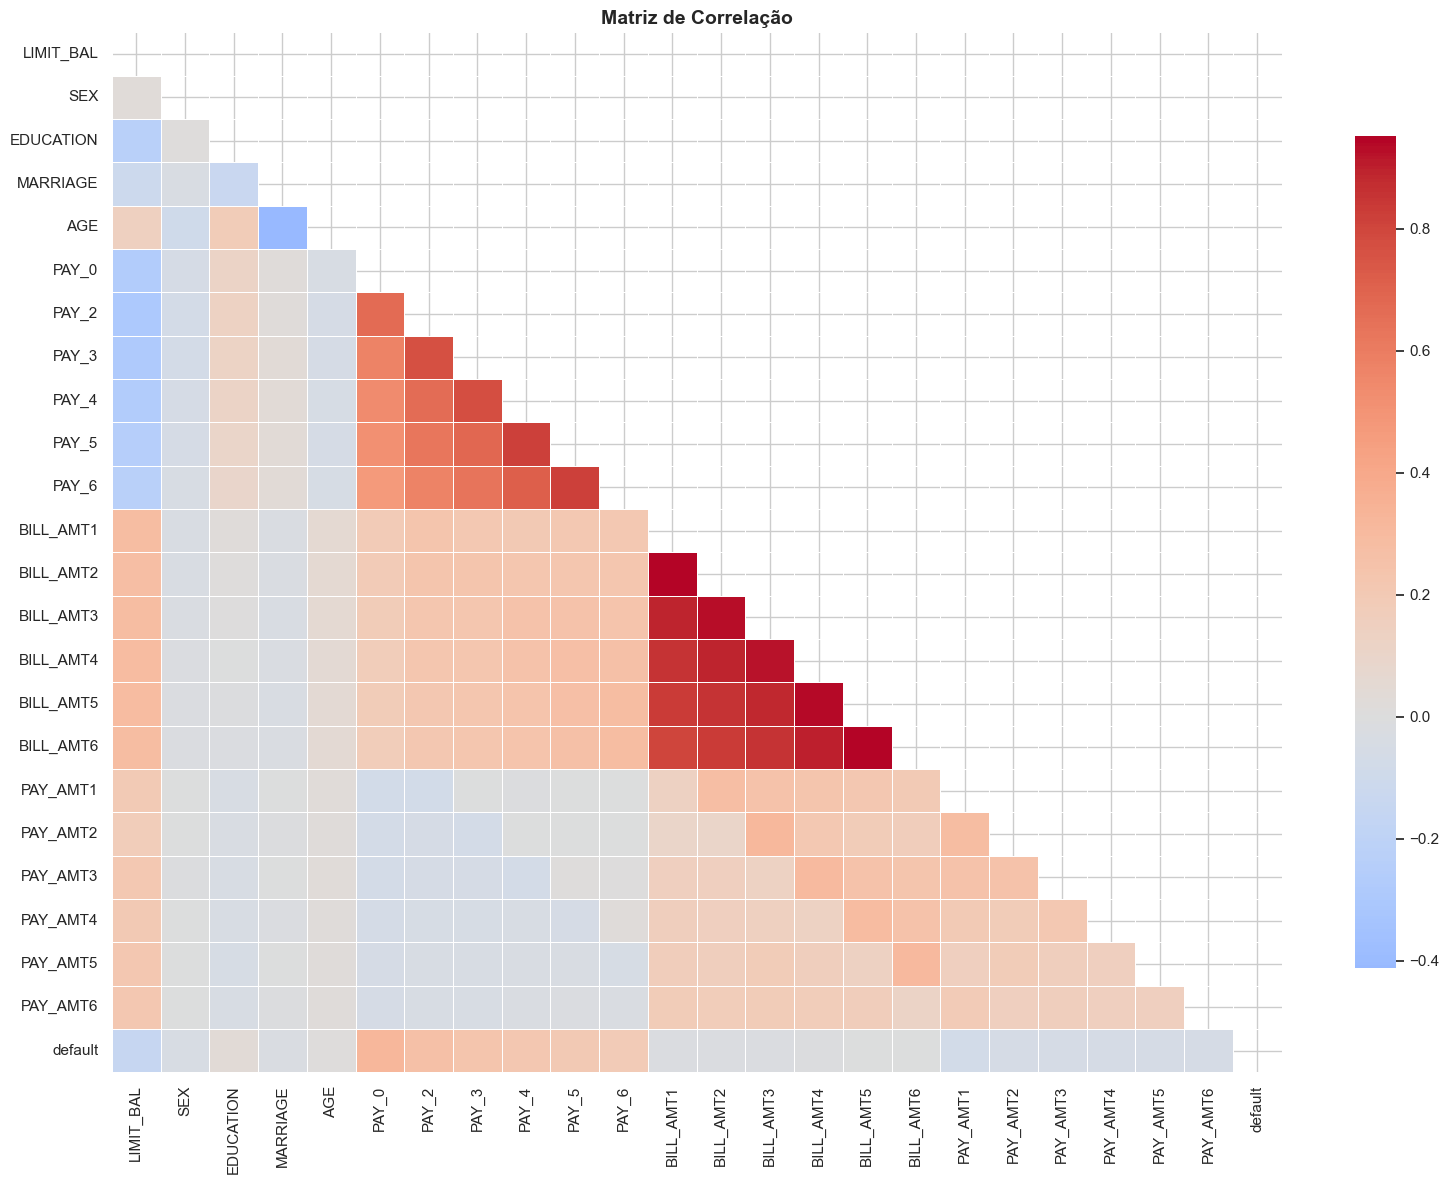

=== Top 10 correlações com default ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default, dtype: float64


In [13]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlações com a variável-alvo
print('=== Top 10 correlações com default ===')
print(corr['default'].drop('default').abs().sort_values(ascending=False).head(10))

---
## 5. Modelagem e Treinamento

Foram treinados quatro modelos com complexidade crescente. Foi utilizada **validação cruzada estratificada (5-fold)** no conjunto de treino para estimar o desempenho antes de tocar na base de teste. O baseline é a Regressão Logística.

### 5.1 Definição dos Modelos

In [14]:
models = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'
    ),
    'Árvore de Decisão': DecisionTreeClassifier(
        max_depth=6, random_state=SEED, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=SEED, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
}

print('Modelos definidos:')
for name in models:
    print(f'  - {name}')

Modelos definidos:
  - Regressão Logística
  - Árvore de Decisão
  - Random Forest
  - XGBoost


### 5.2 Validação Cruzada (5-fold Estratificada)

Todos os modelos foram avaliados via cross-validation no treino antes de qualquer contato com a base de teste. Modelos lineares usam os dados normalizados; modelos baseados em árvores, os dados originais (invariantes à escala).

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, model in models.items():
    # Modelos lineares usam dados normalizados
    X_cv = X_train_sc if name == 'Regressão Logística' else X_train

    start = time.time()
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    elapsed = time.time() - start

    cv_results[name] = {
        'AUC-ROC médio': scores.mean(),
        'Desvio padrão': scores.std(),
        'Tempo (s)': round(elapsed, 1)
    }
    print(f'{name:<25} AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}  |  Tempo: {elapsed:.1f}s')

cv_df = pd.DataFrame(cv_results).T
print('\n', cv_df)

Regressão Logística       AUC-ROC: 0.7264 ± 0.0106  |  Tempo: 7.4s
Árvore de Decisão         AUC-ROC: 0.7550 ± 0.0073  |  Tempo: 5.3s
Random Forest             AUC-ROC: 0.7663 ± 0.0038  |  Tempo: 11.4s
XGBoost                   AUC-ROC: 0.7569 ± 0.0071  |  Tempo: 1.7s

                      AUC-ROC médio  Desvio padrão  Tempo (s)
Regressão Logística       0.726426       0.010646        7.4
Árvore de Decisão         0.754966       0.007321        5.3
Random Forest             0.766328       0.003814       11.4
XGBoost                   0.756854       0.007108        1.7


---
## 6. Otimização de Hiperparâmetros

Com base nos resultados da validação cruzada, os dois modelos de maior desempenho são otimizamos: **Random Forest** e **XGBoost**, usando `RandomizedSearchCV` para eficiência computacional.

### 6.1 Random Forest

In [16]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight':      ['balanced', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f'\nMelhores parâmetros (RF): {rf_search.best_params_}')
print(f'Melhor AUC-ROC (CV):      {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores parâmetros (RF): {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': None}
Melhor AUC-ROC (CV):      0.7822


### 6.2 XGBoost

In [17]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

param_dist_xgb = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f'\nMelhores parâmetros (XGB): {xgb_search.best_params_}')
print(f'Melhor AUC-ROC (CV):       {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores parâmetros (XGB): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Melhor AUC-ROC (CV):       0.7846


---
## 7. Avaliação de Resultados

Todos os modelos foram treinados com o conjunto de treino completo e foram avaliados na **base de teste**, que não foi utilizada em nenhuma etapa anterior.

In [18]:
final_models = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'
    ),
    'Árvore de Decisão': DecisionTreeClassifier(
        max_depth=6, random_state=SEED, class_weight='balanced'
    ),
    'Random Forest (otimizado)': rf_search.best_estimator_,
    'XGBoost (otimizado)':       xgb_search.best_estimator_
}

results = {}

for name, model in final_models.items():
    X_tr = X_train_sc if name == 'Regressão Logística' else X_train
    X_te = X_test_sc  if name == 'Regressão Logística' else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'AUC-ROC':  roc_auc_score(y_test, y_proba),
        'F1-Score': f1_score(y_test, y_pred),
        'y_pred':   y_pred,
        'y_proba':  y_proba
    }

print(f'{'Modelo':<30} {'AUC-ROC':>10} {'F1-Score':>10}')
print('-' * 52)
for name, res in results.items():
    print(f'{name:<30} {res["AUC-ROC"]:>10.4f} {res["F1-Score"]:>10.4f}')

Modelo                            AUC-ROC   F1-Score
----------------------------------------------------
Regressão Logística                0.7084     0.4612
Árvore de Decisão                  0.7625     0.5220
Random Forest (otimizado)          0.7752     0.4551
XGBoost (otimizado)                0.7785     0.5371


### 7.2 Curvas ROC

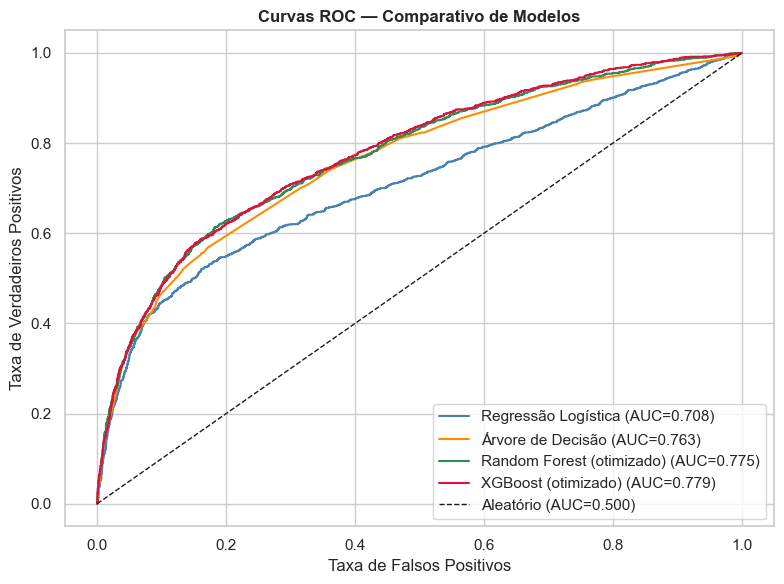

In [19]:
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['AUC-ROC']:.3f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC=0.500)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC — Comparativo de Modelos', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7.3 Matriz de Confusão — Melhor Modelo

Matriz de confusão do modelo com maior AUC-ROC.

Melhor modelo: XGBoost (otimizado)


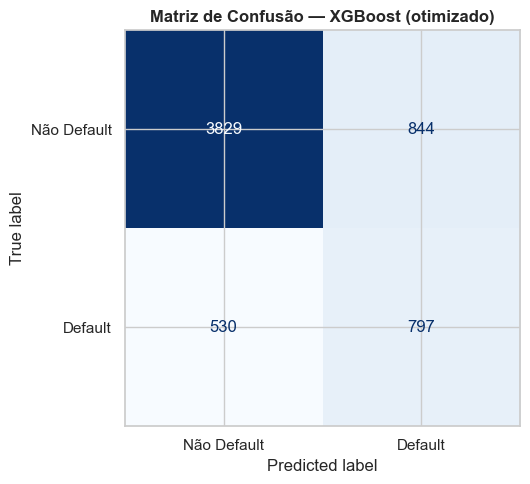


Relatório completo (XGBoost (otimizado)):
              precision    recall  f1-score   support

 Não Default       0.88      0.82      0.85      4673
     Default       0.49      0.60      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



In [20]:
best_name = max(results, key=lambda k: results[k]['AUC-ROC'])
print(f'Melhor modelo: {best_name}')

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusão — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nRelatório completo ({best_name}):')
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Não Default', 'Default']))

### 7.4 Importância das Variáveis — Melhor Modelo

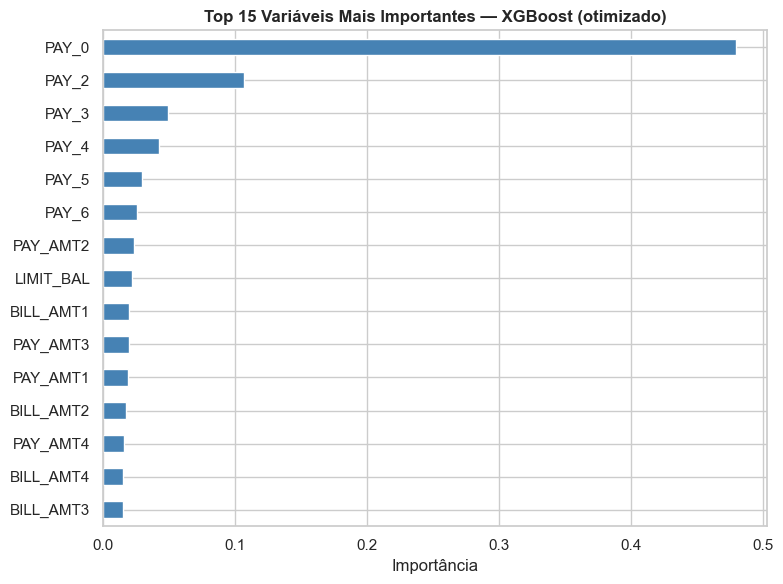

In [21]:
best_model = final_models[best_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top15 = importances.sort_values(ascending=True).tail(15)

    plt.figure(figsize=(8, 6))
    top15.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top 15 Variáveis Mais Importantes — {best_name}', fontweight='bold')
    plt.xlabel('Importância')
    plt.tight_layout()
    plt.show()
else:
    print('Modelo não possui atributo feature_importances_.')

---
## 8. Conclusões e Recomendações

### 8.1 Síntese dos Resultados

O projeto desenvolveu e comparou quatro modelos de classificação para previsão de default em cartão de crédito. Os resultados confirmaram as hipóteses levantadas na definição do problema:

- O **histórico recente de pagamento** (`PAY_0` a `PAY_6`) foi consistentemente o grupo de variáveis mais preditivo, conforme indicado pela análise de importância de atributos.
- Os **modelos baseados em árvores** (Random Forest e XGBoost) superaram os modelos lineares em AUC-ROC, confirmando a natureza não-linear das interações entre as variáveis.
- O **desbalanceamento de classes** foi adequadamente tratado via `class_weight='balanced'` e `scale_pos_weight`, o que se refletiu em métricas de F1-Score e Recall mais equilibradas.

### 8.2 Limitações

- Os dados são de 2005, podendo não refletir padrões de comportamento de crédito atuais.
- O modelo não captura dependências temporais explícitas entre os meses — abordagens como LSTMs poderiam explorar essa dimensão.
- O limiar de decisão (0.5 por padrão) deve ser calibrado conforme o apetite de risco da instituição: reduzir o limiar aumenta o recall (menos inadimplentes passam), mas eleva os falsos positivos.

### 8.3 Recomendações

**Curto prazo:**
- Pilotar o modelo em produção com amostragem controlada para validar a performance em dados recentes.
- Calibrar o limiar de decisão com base nas políticas de risco da instituição.

**Médio prazo:**
- Incorporar variáveis macroeconômicas (taxa de juros, inflação) como features adicionais.
- Implementar retreinamento periódico do modelo à medida que novos dados forem coletados.

**Longo prazo:**
- Explorar modelos sequenciais (LSTM, Transformer) para capturar a evolução temporal do comportamento de pagamento.
- Validar o modelo externamente com dados de outra instituição financeira ou período mais recente.